# Clustering espectral de países según sus gustos musicales en Spotify

**Trabajo Práctico 1 — Álgebra Lineal y Optimización para Data Science (ING-560, UAI)**
**Integrantes:** Max Lastra · Benjamín Nuñez

1. ¿Cuántos grupos sugiere el espectro del Laplaciano (*eigengap*)?
2. ¿Las comunidades se explican mejor por idioma, geografía o clima?
3. ¿Cuánto de la estructura se debe a los éxitos globales?
4. ¿Con quién se agrupa Chile y qué países actúan como puente entre grupos?

**Datos.** *Top Spotify Songs in 73 Countries (Daily Updated)* (Kaggle): Top 50 diario de 72 países entre el
18-10-2023 y el 11-06-2025. Para el clima: mapa Köppen-Geiger 1991–2020, ciudades de GeoNames y temperatura de WorldClim.

**Reproducibilidad.** La primera ejecución descarga todos los datos (≈ 330 MB) en `data/`.
Requiere `numpy pandas matplotlib scipy scikit-learn networkx tifffile imagecodecs`.

## 0. Configuración

In [1]:
import json
import logging
import re
import shutil
import urllib.request
import warnings
import zipfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import tifffile
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as PoligonoMpl
from scipy.sparse.csgraph import connected_components
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score

warnings.filterwarnings('ignore')
logging.getLogger('tifffile').setLevel(logging.ERROR)
SEED = 2025
DATA, FIG, RES = Path('data'), Path('figuras'), Path('resultados')
CLIMA_DIR = DATA / 'clima'
for carpeta in (DATA, FIG, RES, CLIMA_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 120)

PALETA = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
TINTA, TINTA2, MUDO, SUPERFICIE, SIN_DATO = '#0b0b0b', '#52514e', '#898781', '#fcfcfb', '#e9e8e3'
mpl.rcParams.update({
    'font.family': ['Segoe UI', 'DejaVu Sans'], 'font.size': 9.5,
    'axes.facecolor': SUPERFICIE, 'figure.facecolor': 'white', 'axes.edgecolor': '#c3c2b7',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6, 'axes.axisbelow': True, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.labelcolor': TINTA2, 'xtick.color': TINTA2, 'ytick.color': TINTA2,
    'legend.frameon': False, 'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})


def guardar(fig, nombre):
    fig.savefig(FIG / f'{nombre}.png')


def descargar(url, destino):
    """Descarga `url` en `destino` si el archivo aún no existe."""
    destino = Path(destino)
    if not destino.exists():
        print('Descargando', url)
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as r, open(destino, 'wb') as f:
            shutil.copyfileobj(r, f)
    return destino

## 1. Datos de Spotify

Cada fila es *una canción, en el Top 50 de un país, en un día*. Decisiones de limpieza:
- se excluye el Top 50 Global (no es un país);
- se usa todo el período disponible (18-10-2023 a 11-06-2025);
- se conservan solo posiciones ≤ 50 y se eliminan duplicados (país, día, canción);
- cada canción se identifica por *nombre + artistas*, porque una misma canción puede tener varios `spotify_id` según el mercado.

In [2]:
URL_SPOTIFY = 'https://www.kaggle.com/api/v1/datasets/download/asaniczka/top-spotify-songs-in-73-countries-daily-updated'
FECHA_INI, FECHA_FIN = '2023-10-18', '2025-06-11'

csv_spotify = DATA / 'universal_top_spotify_songs.csv'
if not csv_spotify.exists():
    zipfile.ZipFile(descargar(URL_SPOTIFY, DATA / 'spotify_top50.zip')).extract('universal_top_spotify_songs.csv', DATA)

raw = pd.read_csv(csv_spotify, usecols=['spotify_id', 'name', 'artists', 'daily_rank', 'country', 'snapshot_date'],
                  keep_default_na=False, na_values=[''])
df = raw[raw['country'].notna()]
df = df[(df['snapshot_date'] >= FECHA_INI) & (df['snapshot_date'] <= FECHA_FIN) & (df['daily_rank'] <= 50)].copy()
df['cancion'] = df['name'].str.lower().str.strip() + ' — ' + df['artists'].str.lower().str.strip()
df = df.drop_duplicates(['country', 'snapshot_date', 'cancion'])

pd.Series({'Filas originales': len(raw), 'Filas tras la limpieza': len(df), 'Países': df['country'].nunique(),
           'Días': df['snapshot_date'].nunique(), 'spotify_id distintos': df['spotify_id'].nunique(),
           'Canciones (nombre + artistas)': df['cancion'].nunique()}).to_frame('valor')

,valor
Filas originales,2110316
Filas tras la limpieza,2081318
Países,72
Días,583
spotify_id distintos,24977
Canciones (nombre + artistas),23021


## 2. Atributos de los países: continente, idioma y clima

Se usan para evaluar las comunidades (no para construir la red).

**Clima ponderado por población.** A cada ciudad con más de 15.000 habitantes (GeoNames) se le asigna su clase Köppen-Geiger
1991–2020 y su temperatura media anual (WorldClim). Para cada país se calcula la proporción de su población urbana en cada grupo
climático (A Tropical, B Seco, C Templado, D Continental, E Polar) y se asigna el grupo dominante. Un país es **"Variado"** solo si es
imposible encasillarlo: ningún grupo reúne al menos el 60 % de la población **y** la temperatura varía en ±3 °C o más entre sus ciudades.

In [3]:
META = {
    'AR': ('Argentina', 'América Latina', 'Español'), 'BO': ('Bolivia', 'América Latina', 'Español'),
    'BR': ('Brasil', 'América Latina', 'Portugués'), 'CL': ('Chile', 'América Latina', 'Español'),
    'CO': ('Colombia', 'América Latina', 'Español'), 'EC': ('Ecuador', 'América Latina', 'Español'),
    'PE': ('Perú', 'América Latina', 'Español'), 'PY': ('Paraguay', 'América Latina', 'Español'),
    'UY': ('Uruguay', 'América Latina', 'Español'), 'VE': ('Venezuela', 'América Latina', 'Español'),
    'CR': ('Costa Rica', 'América Latina', 'Español'), 'DO': ('Rep. Dominicana', 'América Latina', 'Español'),
    'GT': ('Guatemala', 'América Latina', 'Español'), 'HN': ('Honduras', 'América Latina', 'Español'),
    'MX': ('México', 'América Latina', 'Español'), 'NI': ('Nicaragua', 'América Latina', 'Español'),
    'PA': ('Panamá', 'América Latina', 'Español'), 'SV': ('El Salvador', 'América Latina', 'Español'),
    'CA': ('Canadá', 'Norteamérica', 'Inglés'), 'US': ('Estados Unidos', 'Norteamérica', 'Inglés'),
    'DK': ('Dinamarca', 'Europa', 'Danés'), 'EE': ('Estonia', 'Europa', 'Estonio'), 'FI': ('Finlandia', 'Europa', 'Finés'),
    'GB': ('Reino Unido', 'Europa', 'Inglés'), 'IE': ('Irlanda', 'Europa', 'Inglés'), 'IS': ('Islandia', 'Europa', 'Islandés'),
    'LT': ('Lituania', 'Europa', 'Lituano'), 'LV': ('Letonia', 'Europa', 'Letón'), 'NO': ('Noruega', 'Europa', 'Noruego'),
    'SE': ('Suecia', 'Europa', 'Sueco'), 'AT': ('Austria', 'Europa', 'Alemán'), 'BE': ('Bélgica', 'Europa', 'Neerlandés'),
    'CH': ('Suiza', 'Europa', 'Alemán'), 'DE': ('Alemania', 'Europa', 'Alemán'), 'FR': ('Francia', 'Europa', 'Francés'),
    'LU': ('Luxemburgo', 'Europa', 'Luxemburgués'), 'NL': ('Países Bajos', 'Europa', 'Neerlandés'),
    'BG': ('Bulgaria', 'Europa', 'Búlgaro'), 'BY': ('Bielorrusia', 'Europa', 'Ruso'), 'CZ': ('Chequia', 'Europa', 'Checo'),
    'HU': ('Hungría', 'Europa', 'Húngaro'), 'PL': ('Polonia', 'Europa', 'Polaco'), 'RO': ('Rumania', 'Europa', 'Rumano'),
    'SK': ('Eslovaquia', 'Europa', 'Eslovaco'), 'UA': ('Ucrania', 'Europa', 'Ucraniano'), 'ES': ('España', 'Europa', 'Español'),
    'GR': ('Grecia', 'Europa', 'Griego'), 'IT': ('Italia', 'Europa', 'Italiano'), 'PT': ('Portugal', 'Europa', 'Portugués'),
    'AE': ('Emiratos Árabes', 'Medio Oriente y N. África', 'Árabe'), 'EG': ('Egipto', 'Medio Oriente y N. África', 'Árabe'),
    'IL': ('Israel', 'Medio Oriente y N. África', 'Hebreo'), 'MA': ('Marruecos', 'Medio Oriente y N. África', 'Árabe'),
    'SA': ('Arabia Saudita', 'Medio Oriente y N. África', 'Árabe'), 'TR': ('Turquía', 'Medio Oriente y N. África', 'Turco'),
    'NG': ('Nigeria', 'África Subsahariana', 'Inglés'), 'ZA': ('Sudáfrica', 'África Subsahariana', 'Inglés'),
    'HK': ('Hong Kong', 'Asia', 'Chino'), 'JP': ('Japón', 'Asia', 'Japonés'), 'KR': ('Corea del Sur', 'Asia', 'Coreano'),
    'TW': ('Taiwán', 'Asia', 'Chino'), 'ID': ('Indonesia', 'Asia', 'Indonesio'), 'MY': ('Malasia', 'Asia', 'Malayo'),
    'PH': ('Filipinas', 'Asia', 'Filipino'), 'SG': ('Singapur', 'Asia', 'Inglés'), 'TH': ('Tailandia', 'Asia', 'Tailandés'),
    'VN': ('Vietnam', 'Asia', 'Vietnamita'), 'IN': ('India', 'Asia', 'Hindi'), 'PK': ('Pakistán', 'Asia', 'Urdu'),
    'KZ': ('Kazajistán', 'Asia', 'Kazajo'), 'AU': ('Australia', 'Oceanía', 'Inglés'), 'NZ': ('Nueva Zelanda', 'Oceanía', 'Inglés'),
}
meta = pd.DataFrame.from_dict(META, orient='index', columns=['nombre', 'continente', 'idioma'])
assert set(meta.index) == set(df['country'].unique())

In [4]:
URL_KOPPEN = 'https://ndownloader.figshare.com/files/42602809'
URL_CIUDADES = 'https://download.geonames.org/export/dump/cities15000.zip'
URL_WORLDCLIM = 'https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_10m_bio.zip'
f_koppen, f_leyenda = CLIMA_DIR / 'koppen_geiger_0p01.tif', CLIMA_DIR / 'legend.txt'
if not f_koppen.exists():
    with zipfile.ZipFile(descargar(URL_KOPPEN, CLIMA_DIR / 'koppen_geiger_tif.zip')) as z:
        f_koppen.write_bytes(z.read('1991_2020/koppen_geiger_0p01.tif'))
        f_leyenda.write_bytes(z.read('legend.txt'))
f_ciudades = CLIMA_DIR / 'cities15000.txt'
if not f_ciudades.exists():
    zipfile.ZipFile(descargar(URL_CIUDADES, CLIMA_DIR / 'cities15000.zip')).extract('cities15000.txt', CLIMA_DIR)
f_temp = CLIMA_DIR / 'wc2.1_10m_bio_1.tif'
if not f_temp.exists():
    zipfile.ZipFile(descargar(URL_WORLDCLIM, CLIMA_DIR / 'wc2.1_10m_bio.zip')).extract('wc2.1_10m_bio_1.tif', CLIMA_DIR)

LEYENDA = {int(m.group(1)): m.group(2) for m in re.finditer(r'^\s*(\d+):\s+(\w+)', f_leyenda.read_text(encoding='utf-8'), re.M)}
GRUPOS = {'A': 'Tropical', 'B': 'Seco', 'C': 'Templado', 'D': 'Continental', 'E': 'Polar'}
cols = ['id', 'nombre', 'ascii', 'alt', 'lat', 'lon', 'fclase', 'fcodigo', 'cc', 'cc2', 'a1', 'a2', 'a3', 'a4', 'poblacion', 'elev', 'dem', 'tz', 'mod']
ciudades = pd.read_csv(f_ciudades, sep='\t', header=None, names=cols, keep_default_na=False, na_values=[''],
                       usecols=['lat', 'lon', 'fcodigo', 'cc', 'poblacion'])
# se excluyen sectores de ciudades (PPLX) y localidades históricas o abandonadas
ciudades = ciudades[~ciudades['fcodigo'].isin(['PPLX', 'PPLH', 'PPLQ', 'PPLW']) & ciudades['cc'].isin(meta.index)].copy()


def muestrear(raster, res, lat, lon, invalido, moda):
    """Valor de un raster global en cada punto; si cae en el mar, usa la celda terrestre más cercana."""
    i = np.clip(((90 - lat) / res).astype(int), 0, raster.shape[0] - 1)
    j = np.clip(((lon + 180) / res).astype(int), 0, raster.shape[1] - 1)
    v = raster[i, j].astype(float)
    for p in np.where(invalido(v))[0]:
        for r in range(1, 9):
            w = raster[max(i[p] - r, 0):i[p] + r + 1, max(j[p] - r, 0):j[p] + r + 1].ravel().astype(float)
            w = w[~invalido(w)]
            if w.size:
                v[p] = np.bincount(w.astype(int)).argmax() if moda else w.mean()
                break
    return v


ciudades['koppen'] = pd.Series(muestrear(tifffile.imread(f_koppen), 0.01, ciudades['lat'].values, ciudades['lon'].values,
                                         lambda v: v == 0, moda=True), index=ciudades.index).map(LEYENDA)
ciudades['temp'] = muestrear(tifffile.imread(f_temp), 1 / 6, ciudades['lat'].values, ciudades['lon'].values,
                             lambda v: v < -100, moda=False)
ciudades = ciudades.dropna(subset=['koppen', 'temp'])
ciudades['grupo'] = ciudades['koppen'].str[0]

filas = {}
for cc, dd in ciudades.groupby('cc'):
    w = dd['poblacion']
    prop = w.groupby(dd['grupo']).sum() / w.sum()
    t_media = np.average(dd['temp'], weights=w)
    filas[cc] = {'grupo_dom': prop.idxmax(), 'prop_dom': prop.max(), 'temp_media': t_media,
                 'temp_desv': np.sqrt(np.average((dd['temp'] - t_media) ** 2, weights=w))}
clima = pd.DataFrame(filas).T
clima[['prop_dom', 'temp_media', 'temp_desv']] = clima[['prop_dom', 'temp_media', 'temp_desv']].astype(float)
variado = (clima['prop_dom'] < 0.60) & (clima['temp_desv'] >= 3.0)
clima['clima'] = np.where(variado, 'Variado', clima['grupo_dom'].map(GRUPOS))
meta = meta.join(clima[['clima', 'prop_dom', 'temp_desv']])
meta.to_csv(RES / 'paises_atributos.csv', encoding='utf-8-sig')
print(meta['clima'].value_counts().to_dict())
meta.loc[['US', 'BR', 'MX', 'CL'], ['nombre', 'clima', 'prop_dom', 'temp_desv']].round(2)

{'Templado': 27, 'Tropical': 17, 'Continental': 15, 'Seco': 8, 'Variado': 5}


,nombre,clima,prop_dom,temp_desv
US,Estados Unidos,Variado,0.53,4.57
BR,Brasil,Tropical,0.63,2.95
MX,México,Variado,0.49,3.58
CL,Chile,Seco,0.50,1.82


## 3. Construcción de la red

- **Perfil de cada país:** $x_c(s)$ = número de días que la canción $s$ estuvo en el Top 50 del país $c$.
- **Similitud:** coseno, $s_{ij} = \langle x_i, x_j\rangle / (\|x_i\|\|x_j\|)$. Compara proporciones, así que no importa que
  algunos países tengan menos días de datos.
- **Red:** cada país se conecta con sus $k$ países más parecidos (simetrizando), con peso $a_{ij} = s_{ij}$. La red queda
  no dirigida, ponderada, sin *loops* y sin nodos aislados.
- **Elección de $k$:** el menor $k$ que deja la red conexa.

In [5]:
X = pd.crosstab(df['country'], df['cancion'])        # países × canciones (días en el Top 50)
paises = X.index.tolist()
n = len(paises)
meta = meta.loc[paises]
idx = {p: i for i, p in enumerate(paises)}


def similitud_coseno(Xm):
    Xm = np.asarray(Xm, dtype=float)
    Xn = Xm / np.linalg.norm(Xm, axis=1, keepdims=True)
    Sm = Xn @ Xn.T
    np.fill_diagonal(Sm, 0.0)
    return Sm


def grafo_knn(Sm, k):
    """Red simétrica de k vecinos más parecidos, con pesos = similitud."""
    Am = np.zeros_like(Sm)
    for i in range(len(Sm)):
        vecinos = [j for j in np.argsort(-Sm[i]) if j != i][:k]
        vecinos = [j for j in vecinos if Sm[i, j] > 0]
        Am[i, vecinos] = Sm[i, vecinos]
    return np.maximum(Am, Am.T)


def laplacianos(Am):
    d = Am.sum(axis=1)
    L = np.diag(d) - Am
    Dmh = np.diag(1 / np.sqrt(d))
    return d, L, np.eye(len(Am)) - Dmh @ Am @ Dmh


S = similitud_coseno(X)
print(f'X: {X.shape[0]} países × {X.shape[1]:,} canciones | similitud mediana entre pares = {np.median(S[np.triu_indices(n, 1)]):.3f}')

conect = []
for k in range(2, 21):
    nc, etiquetas = connected_components(grafo_knn(S, k), directed=False)
    menor = [paises[i] for i in range(n) if etiquetas[i] != np.bincount(etiquetas).argmax()]
    conect.append({'k': k, 'componentes': nc, 'componente menor': ' '.join(menor)})
conect = pd.DataFrame(conect).set_index('k')
K_VECINOS = int(conect.index[conect['componentes'] == 1][0])
print('Menor k que deja la red conexa:', K_VECINOS)
conect.loc[[3, 5, 8, 11, 12]]

X: 72 países × 23,021 canciones | similitud mediana entre pares = 0.056
Menor k que deja la red conexa: 12


,componentes,componente menor
k,,
3,2,AR BO CL CO CR DO EC ES GT HN MX NI PA PE PY SV UY VE
5,2,AR BO CL CO CR DO EC ES GT HN MX NI PA PE PY SV UY VE
8,2,AR BO CL CO CR DO EC ES GT HN MX NI PA PE PY SV UY VE
11,2,AR BO CL CO CR DO EC ES GT HN MX NI PA PE PY SV UY VE
12,1,


Para $k \le 11$ la red tiene **dos componentes conexas**: el bloque formado por los países hispanohablantes de América Latina más
España, y el resto del mundo. Se usa $k = 12$, el menor valor con la red conexa.

Red final: 72 nodos, 665 aristas, conexa = True


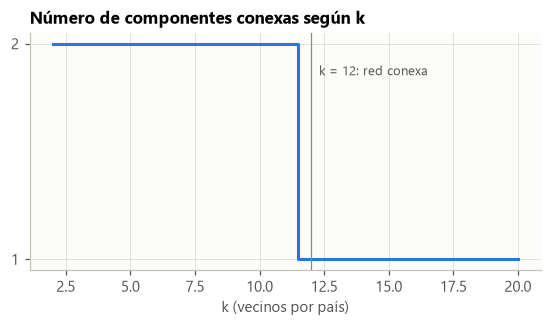

In [6]:
A = grafo_knn(S, K_VECINOS)
G = nx.from_numpy_array(A)
d, L, L_sym = laplacianos(A)
print(f'Red final: {n} nodos, {G.number_of_edges()} aristas, conexa = {nx.is_connected(G)}')

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.step(conect.index, conect['componentes'], where='mid', color=PALETA[0], lw=2)
ax.axvline(K_VECINOS, color=MUDO, lw=0.8)
ax.text(K_VECINOS + 0.3, 1.9, f'k = {K_VECINOS}: red conexa', color=TINTA2, fontsize=8.5, va='top')
ax.set_yticks([1, 2])
ax.set_xlabel('k (vecinos por país)')
ax.set_title('Número de componentes conexas según k')
guardar(fig, 'fig01_conectividad')
plt.show()

## 4. Matrices, espectro y *eigengap*

$A$ = adyacencia ponderada, $D = \mathrm{diag}(d_i)$ con $d_i = \sum_j a_{ij}$, $L = D - A$ y
$L_{sym} = I - D^{-1/2} A D^{-1/2}$. Se usa $L_{sym}$ porque los grados son muy heterogéneos. El *eigengap* indica cuántos
grupos hay: se busca el mayor salto $\lambda_{k+1} - \lambda_k$.

λ_1..λ_8 = [0.000e+00 3.000e-04 3.133e-01 3.839e-01 6.606e-01 7.053e-01 7.326e-01
 8.118e-01] | mayores saltos tras k = [2, 4]


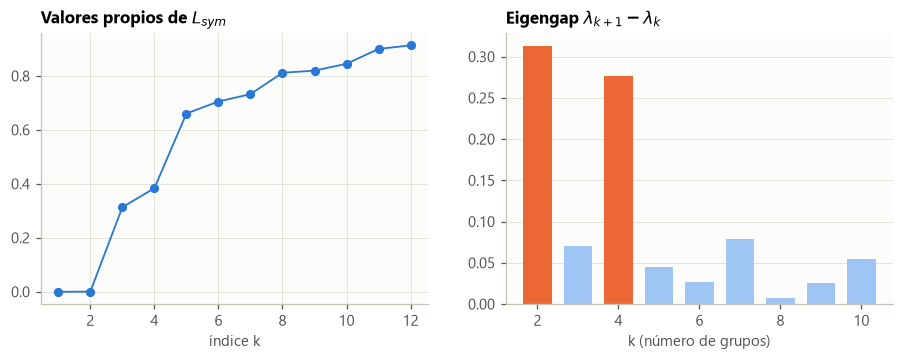

In [7]:
lam, V = np.linalg.eigh(L_sym)
gaps = np.diff(lam)
ranking_k = [int(k) for k in np.argsort(gaps[1:10])[::-1] + 2]
K_MACRO, K_FINAL = ranking_k[0], next(k for k in ranking_k if k > ranking_k[0])
print('λ_1..λ_8 =', lam[:8].round(4), f'| mayores saltos tras k = {ranking_k[:2]}')

fig, axs = plt.subplots(1, 2, figsize=(10, 3.2))
axs[0].plot(range(1, 13), lam[:12], color=PALETA[0], marker='o', ms=5, lw=1.2)
axs[0].set_xlabel('índice k')
axs[0].set_title(r'Valores propios de $L_{sym}$')
axs[1].bar(range(2, 11), gaps[1:10], width=0.7,
           color=[PALETA[1] if k in (K_MACRO, K_FINAL) else '#9ec5f4' for k in range(2, 11)])
axs[1].set_xlabel('k (número de grupos)')
axs[1].set_title(r'Eigengap $\lambda_{k+1}-\lambda_k$')
axs[1].grid(axis='x', visible=False)
guardar(fig, 'fig02_espectro_eigengap')
plt.show()

## 5. Vector de Fiedler

Segundo vector propio (normalizado por $D^{-1/2}$). Su signo da la bipartición.

Grupo positivo del vector de Fiedler: ['AR', 'BO', 'CL', 'CO', 'CR', 'DO', 'EC', 'ES', 'GT', 'HN', 'MX', 'NI', 'PA', 'PE', 'PY', 'SV', 'UY', 'VE']


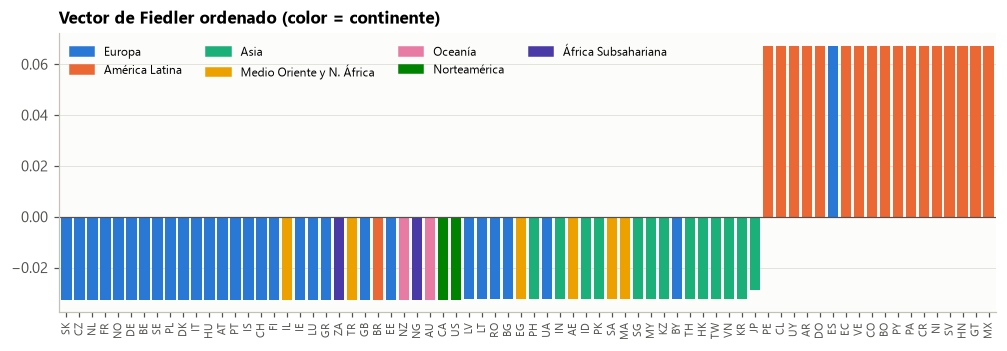

In [8]:
fiedler = np.diag(1 / np.sqrt(d)) @ V[:, 1]
fiedler = fiedler * np.sign(fiedler[idx['CL']])
print('Grupo positivo del vector de Fiedler:', sorted(paises[i] for i in np.where(fiedler > 0)[0]))

continentes = list(meta['continente'].value_counts().index)
color_cont = {c: PALETA[i] for i, c in enumerate(continentes)}
o = np.argsort(fiedler)
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.bar(range(n), fiedler[o], color=[color_cont[meta.iloc[i]['continente']] for i in o], width=0.8)
ax.axhline(0, color=TINTA2, lw=0.8)
ax.set_xticks(range(n), [paises[i] for i in o], rotation=90, fontsize=7)
ax.set_xlim(-0.6, n - 0.4)
ax.grid(axis='x', visible=False)
ax.legend(handles=[Patch(color=color_cont[c], label=c) for c in continentes], ncols=4, fontsize=8, loc='upper left')
ax.set_title('Vector de Fiedler ordenado (color = continente)')
guardar(fig, 'fig03_fiedler')
plt.show()

## 6. Clustering espectral

1. $U$ = los $k$ primeros vectores propios de $L_{sym}$; se normaliza cada fila a norma 1.
2. La fila $i$ de $U$ es la representación espectral del país $i$ (un punto en $\mathbb{R}^k$).
3. $k$-means sobre las filas (50 inicializaciones).

In [9]:
def embedding_espectral(Am, k, tipo='sym'):
    dd = Am.sum(axis=1)
    if tipo == 'L':                                   # Laplaciano no normalizado
        U = np.linalg.eigh(np.diag(dd) - Am)[1][:, :k]
    else:                                             # Laplaciano normalizado L_sym, filas normalizadas
        Dmh = np.diag(1 / np.sqrt(dd))
        U = np.linalg.eigh(np.eye(len(Am)) - Dmh @ Am @ Dmh)[1][:, :k]
        U = U / np.linalg.norm(U, axis=1, keepdims=True)
    return U


def clustering_espectral(Am, k, tipo='sym'):
    return KMeans(n_clusters=k, n_init=50, random_state=SEED).fit_predict(embedding_espectral(Am, k, tipo))


ANCLAS = [('MX', 'Hispano'), ('US', 'Europa y mundo anglosajón'), ('JP', 'Asia, Medio Oriente y Europa del Este'), ('IN', 'Sur de Asia')]
ANCLAS_LOCAL = [('MX', 'Hispano'), ('US', 'Anglosajón y nórdico'), ('JP', 'Asia Oriental y Sudeste Asiático'), ('IN', 'Sur de Asia'),
                ('BR', 'Lusófono'), ('DE', 'Europa continental'), ('TR', 'Europa del Este, Turquía y mundo árabe')]


def ordenar_y_nombrar(lab, anclas):
    """Ordena las etiquetas según países 'ancla' (solo para rotular y dar colores estables)."""
    orden = []
    for ancla, _ in anclas:
        if lab[idx[ancla]] not in orden:
            orden.append(lab[idx[ancla]])
    orden += [c for c in np.unique(lab) if c not in orden]
    nueva = np.array([orden.index(c) for c in lab])
    nombres = {}
    for ancla, nombre in anclas:
        nombres.setdefault(nueva[idx[ancla]], nombre)
    return nueva, {c: nombres.get(c, f'Grupo {c + 1}') for c in np.unique(nueva)}


def tabla_comunidades(lab, nombres):
    return pd.DataFrame([{'comunidad': nombres[c], 'tamaño': int((lab == c).sum()),
                          'países': ', '.join(sorted(meta['nombre'].iloc[np.where(lab == c)[0]]))} for c in np.unique(lab)])


lab2, nombres2 = ordenar_y_nombrar(clustering_espectral(A, K_MACRO), [('MX', 'Hispano'), ('US', 'Resto del mundo')])
lab4, nombres4 = ordenar_y_nombrar(clustering_espectral(A, K_FINAL), ANCLAS)
display(tabla_comunidades(lab2, nombres2))
tabla_comunidades(lab4, nombres4)

,comunidad,tamaño,países
0,Hispano,18,"Argentina, Bolivia, Chile, Colombia, Costa Rica, Ecuador, El Salvador, España, Guatemala, Honduras, México, Nicaragu..."
1,Resto del mundo,54,"Alemania, Arabia Saudita, Australia, Austria, Bielorrusia, Brasil, Bulgaria, Bélgica, Canadá, Chequia, Corea del Sur..."


,comunidad,tamaño,países
0,Hispano,18,"Argentina, Bolivia, Chile, Colombia, Costa Rica, Ecuador, El Salvador, España, Guatemala, Honduras, México, Nicaragu..."
1,Europa y mundo anglosajón,33,"Alemania, Australia, Austria, Brasil, Bélgica, Canadá, Chequia, Dinamarca, Eslovaquia, Estados Unidos, Estonia, Finl..."
2,"Asia, Medio Oriente y Europa del Este",19,"Arabia Saudita, Bielorrusia, Bulgaria, Corea del Sur, Egipto, Emiratos Árabes, Filipinas, Hong Kong, Indonesia, Japó..."
3,Sur de Asia,2,"India, Pakistán"


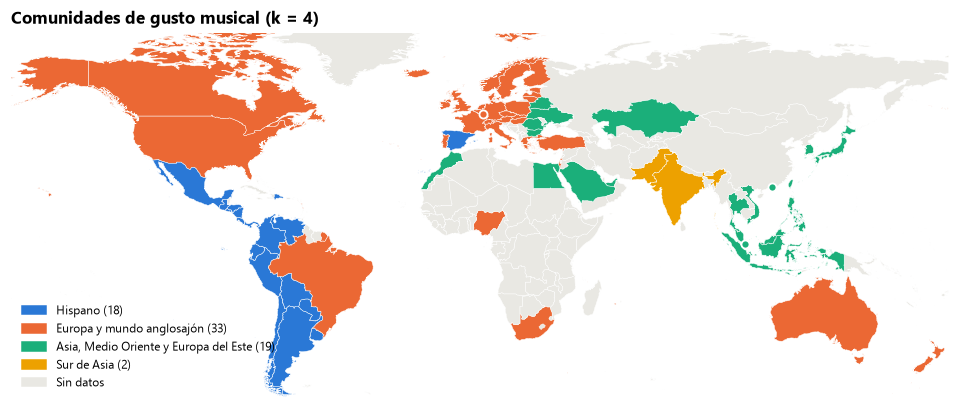

In [10]:
MUNDO = json.loads(descargar('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson',
                             DATA / 'ne_50m_admin_0_countries.geojson').read_text(encoding='utf-8'))
PEQUENOS = {'SG': (103.82, 1.35), 'HK': (114.17, 22.32), 'LU': (6.13, 49.61)}


def mapa(lab, nombres, titulo, archivo):
    colores = {paises[i]: PALETA[lab[i]] for i in range(n)}
    fig, ax = plt.subplots(figsize=(11, 5.2))
    for feat in MUNDO['features']:
        iso = feat['properties'].get('ISO_A2_EH')
        if iso == 'AQ':
            continue
        geom = feat['geometry']
        for pol in (geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]):
            ax.add_patch(PoligonoMpl(np.array(pol[0]), closed=True, facecolor=colores.get(iso, SIN_DATO), edgecolor='white', linewidth=0.3))
    for iso, (lo, la) in PEQUENOS.items():
        ax.scatter(lo, la, s=28, color=colores[iso], edgecolor='white', linewidth=1.2, zorder=3)
    ax.set_xlim(-170, 180)
    ax.set_ylim(-57, 80)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo)
    ax.legend(handles=[Patch(color=PALETA[c], label=f'{nombres[c]} ({(lab == c).sum()})') for c in np.unique(lab)]
              + [Patch(color=SIN_DATO, label='Sin datos')], loc='lower left', fontsize=8)
    guardar(fig, archivo)
    plt.show()


mapa(lab4, nombres4, f'Comunidades de gusto musical (k = {K_FINAL})', 'fig04_mapa_k4')

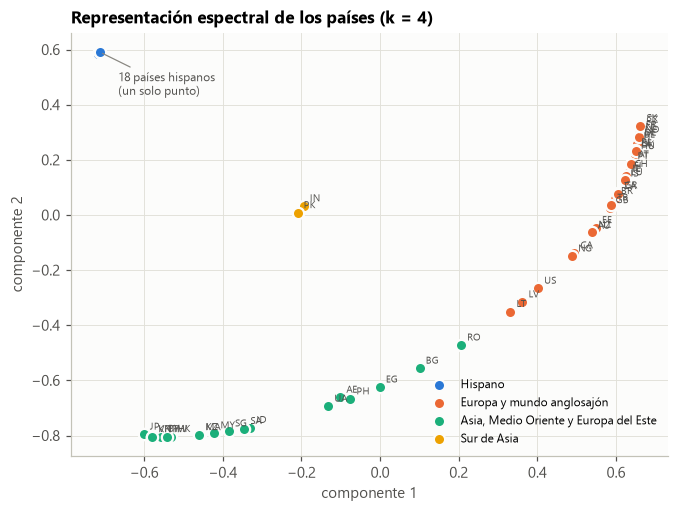

In [11]:
# Representación espectral (k = 4): filas normalizadas de U proyectadas a 2D con PCA
U4 = embedding_espectral(A, K_FINAL)
U4c = U4 - U4.mean(axis=0)
P2 = U4c @ np.linalg.svd(U4c, full_matrices=False)[2][:2].T
fig, ax = plt.subplots(figsize=(7, 5))
for c in np.unique(lab4):
    m = lab4 == c
    ax.scatter(P2[m, 0], P2[m, 1], s=55, color=PALETA[c], edgecolor=SUPERFICIE, linewidth=1.5, label=nombres4[c], zorder=3)
for i in range(n):
    if lab4[i] != lab4[idx['MX']]:
        ax.annotate(paises[i], P2[i], xytext=(4, 3), textcoords='offset points', fontsize=6.5, color=TINTA2)
ax.annotate('18 países hispanos\n(un solo punto)', P2[lab4 == lab4[idx['MX']]].mean(axis=0), xytext=(12, -28),
            textcoords='offset points', fontsize=8, color=TINTA2, arrowprops=dict(arrowstyle='-', color=MUDO, lw=0.8))
ax.set_xlabel('componente 1')
ax.set_ylabel('componente 2')
ax.legend(fontsize=8)
ax.set_title('Representación espectral de los países (k = 4)')
guardar(fig, 'fig05_representacion_espectral')
plt.show()

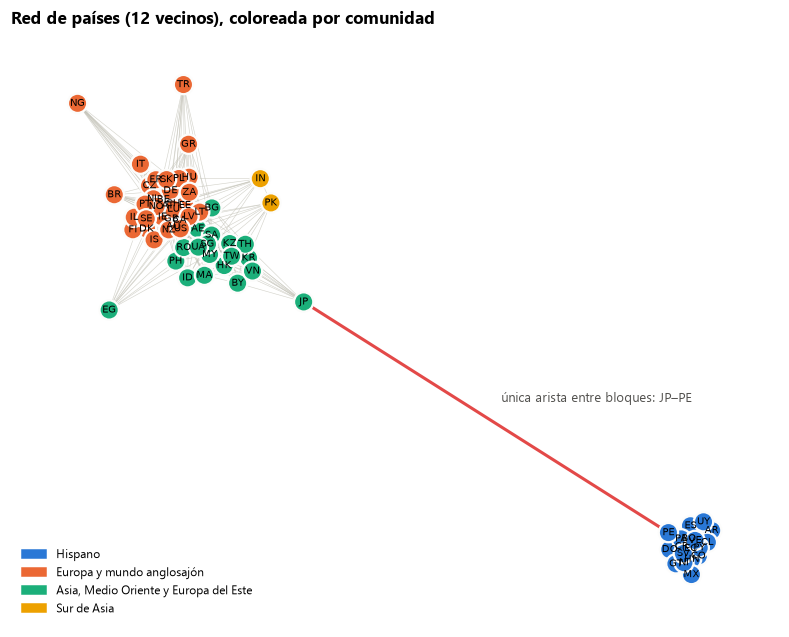

JP–PE: similitud = 0.0341


,días JP,días PE,aporte
cancion,,,
who — jimin,309,309,0.0130
"seven (feat. latto) (explicit ver.) — jung kook, latto",449,197,0.0121
"apt. — rosé, bruno mars",216,169,0.0050
running wild — jin,163,57,0.0013
standing next to you — jung kook,78,103,0.0011


In [12]:
pos = nx.spring_layout(G, weight='weight', seed=SEED, k=0.35, iterations=300)
puentes = [(u, v) for u, v in G.edges() if lab2[u] != lab2[v]]
fig, ax = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(G, pos, ax=ax, width=0.4, edge_color='#c3c2b7', alpha=0.7)
nx.draw_networkx_edges(G, pos, edgelist=puentes, ax=ax, width=2, edge_color=PALETA[7])
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=160, node_color=[PALETA[lab4[i]] for i in range(n)], edgecolors=SUPERFICIE, linewidths=1.5)
nx.draw_networkx_labels(G, pos, labels={i: paises[i] for i in range(n)}, font_size=6.5, ax=ax)
for u, v in puentes:
    ax.annotate(f'única arista entre bloques: {paises[u]}–{paises[v]}', (pos[u] + pos[v]) / 2, xytext=(10, 10),
                textcoords='offset points', fontsize=8.5, color=TINTA2)
ax.legend(handles=[Patch(color=PALETA[c], label=nombres4[c]) for c in np.unique(lab4)], loc='lower left', fontsize=8)
ax.set_title(f'Red de países ({K_VECINOS} vecinos), coloreada por comunidad')
ax.axis('off')
guardar(fig, 'fig06_red')
plt.show()

# Canciones que sostienen la arista entre bloques (aporte de cada canción a la similitud coseno)
for u, v in puentes:
    pa, pb = paises[u], paises[v]
    aporte = X.loc[pa] * X.loc[pb] / (np.linalg.norm(X.loc[pa]) * np.linalg.norm(X.loc[pb]))
    tabla = pd.DataFrame({f'días {pa}': X.loc[pa], f'días {pb}': X.loc[pb], 'aporte': aporte})
    print(f'{pa}–{pb}: similitud = {S[u, v]:.4f}')
    display(tabla[tabla['aporte'] > 0].sort_values('aporte', ascending=False).head(5).round(4))

## 7. Evaluación

- **AMI** (información mutua ajustada) entre las comunidades y cada atributo externo: 0 = como al azar, 1 = coincidencia perfecta.
- **Modularidad** $Q$: qué tanto peso queda dentro de las comunidades respecto de lo esperado al azar.

In [13]:
def evaluar(lab, Am=A):
    r = {f'AMI {a}': adjusted_mutual_info_score(meta[a], lab) for a in ['continente', 'idioma', 'clima']}
    r['modularidad'] = nx.community.modularity(nx.from_numpy_array(Am), [set(np.where(lab == c)[0]) for c in np.unique(lab)], weight='weight')
    r['tamaños'] = ' / '.join(map(str, np.bincount(lab)))
    return r


evaluacion = pd.DataFrame({f'k = {K_MACRO}': evaluar(lab2), f'k = {K_FINAL}': evaluar(lab4)})
evaluacion

,k = 2,k = 4
AMI continente,0.401128,0.513757
AMI idioma,0.169357,0.313408
AMI clima,0.131139,0.189258
modularidad,0.439164,0.485449
tamaños,18 / 54,18 / 33 / 19 / 2


In [14]:
pd.crosstab(pd.Series([nombres4[c] for c in lab4], index=paises, name='comunidad'), meta['continente'])

continente,América Latina,Asia,Europa,Medio Oriente y N. África,Norteamérica,Oceanía,África Subsahariana
comunidad,,,,,,,
"Asia, Medio Oriente y Europa del Este",0,11,4,4,0,0,0
Europa y mundo anglosajón,1,0,24,2,2,2,2
Hispano,17,0,1,0,0,0,0
Sur de Asia,0,2,0,0,0,0,0


## 8. Diseño experimental

**E1 — Laplaciano no normalizado ($L$) vs normalizado ($L_{sym}$).**

In [15]:
filas_e1 = []
for tipo, nombre in [('L', 'L = D − A (no normalizado)'), ('sym', 'L_sym (normalizado)')]:
    for k in [K_MACRO, K_FINAL]:
        lab_e = clustering_espectral(A, k, tipo)
        aislados = [paises[i] for c in np.unique(lab_e) if (lab_e == c).sum() == 1 for i in np.where(lab_e == c)[0]]
        filas_e1.append({'Laplaciano': nombre, 'k': k, **evaluar(lab_e), 'grupos de 1 país': ', '.join(aislados) or '—'})
e1 = pd.DataFrame(filas_e1)
e1.round(3)

,Laplaciano,k,AMI continente,AMI idioma,AMI clima,modularidad,tamaños,grupos de 1 país
0,L = D − A (no normalizado),2,0.401,0.169,0.131,0.439,54 / 18,—
1,L = D − A (no normalizado),4,0.428,0.171,0.123,0.439,52 / 1 / 18 / 1,"NG, TR"
2,L_sym (normalizado),2,0.401,0.169,0.131,0.439,54 / 18,—
3,L_sym (normalizado),4,0.514,0.313,0.189,0.485,33 / 18 / 19 / 2,—


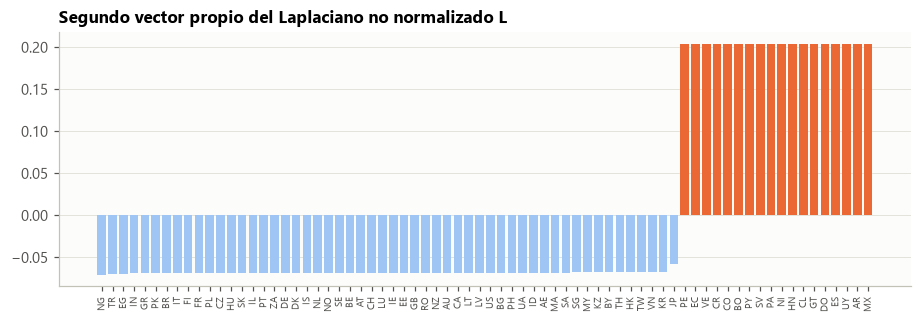

In [16]:
U_L = embedding_espectral(A, 2, 'L')
v2 = U_L[:, 1] * np.sign(U_L[idx['CL'], 1])
o = np.argsort(v2)
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(n), v2[o], color=[PALETA[1] if x > 0 else '#9ec5f4' for x in v2[o]], width=0.8)
ax.set_xticks(range(n), [paises[i] for i in o], rotation=90, fontsize=6.5)
ax.grid(axis='x', visible=False)
ax.set_title('Segundo vector propio del Laplaciano no normalizado L')
guardar(fig, 'fig07_laplaciano_no_normalizado')
plt.show()

**E2 — Éxitos globales.** Se eliminan las canciones que aparecieron en el Top 50 de al menos el 30 % de los países y se repite todo
el procedimiento (misma regla de 12 vecinos; $k$ elegido por *eigengap*).

In [17]:
globalidad = (X > 0).sum(axis=0) / n
print('Canciones más globales (% de países):')
display((globalidad.sort_values(ascending=False).head(5) * 100).round(1).to_frame('% de países'))

X_local = X.loc[:, globalidad < 0.30]
S_local = similitud_coseno(X_local)
A_local = grafo_knn(S_local, K_VECINOS)
lam_local = np.linalg.eigvalsh(laplacianos(A_local)[2])
k_local = int(np.argmax(np.diff(lam_local)[1:10]) + 2)
lab_local, nombres_local = ordenar_y_nombrar(clustering_espectral(A_local, k_local), ANCLAS_LOCAL)
print(f'Canciones eliminadas: {X.shape[1] - X_local.shape[1]} | similitud mediana: '
      f'{np.median(S[np.triu_indices(n, 1)]):.3f} → {np.median(S_local[np.triu_indices(n, 1)]):.3f} | eigengap → k = {k_local}')
e2 = pd.DataFrame({'con todas las canciones (k = 4)': evaluar(lab4), f'sin éxitos globales (k = {k_local})': evaluar(lab_local, A_local)})
display(e2)
tabla_comunidades(lab_local, nombres_local)

Canciones más globales (% de países):


,% de países
cancion,
"die with a smile — lady gaga, bruno mars",95.8
"apt. — rosé, bruno mars",93.1
not like us — kendrick lamar,91.7
"fortnight (feat. post malone) — taylor swift, post malone",88.9
all i want for christmas is you — mariah carey,87.5


Canciones eliminadas: 313 | similitud mediana: 0.056 → 0.000 | eigengap → k = 7


,con todas las canciones (k = 4),sin éxitos globales (k = 7)
AMI continente,0.513757,0.510634
AMI idioma,0.313408,0.449564
AMI clima,0.189258,0.203995
modularidad,0.485449,0.474197
tamaños,18 / 33 / 19 / 2,19 / 13 / 10 / 3 / 2 / 15 / 10


,comunidad,tamaño,países
0,Hispano,19,"Argentina, Bolivia, Chile, Colombia, Costa Rica, Ecuador, El Salvador, España, Guatemala, Honduras, Italia, México, ..."
1,Anglosajón y nórdico,13,"Australia, Canadá, Dinamarca, Estados Unidos, Irlanda, Islandia, Israel, Nigeria, Noruega, Nueva Zelanda, Reino Unid..."
2,Asia Oriental y Sudeste Asiático,10,"Corea del Sur, Filipinas, Hong Kong, Indonesia, Japón, Malasia, Singapur, Tailandia, Taiwán, Vietnam"
3,Sur de Asia,3,"Emiratos Árabes, India, Pakistán"
4,Lusófono,2,"Brasil, Portugal"
5,Europa continental,15,"Alemania, Austria, Bélgica, Chequia, Eslovaquia, Estonia, Finlandia, Francia, Grecia, Hungría, Luxemburgo, Marruecos..."
6,"Europa del Este, Turquía y mundo árabe",10,"Arabia Saudita, Bielorrusia, Bulgaria, Egipto, Kazajistán, Letonia, Lituania, Rumania, Turquía, Ucrania"


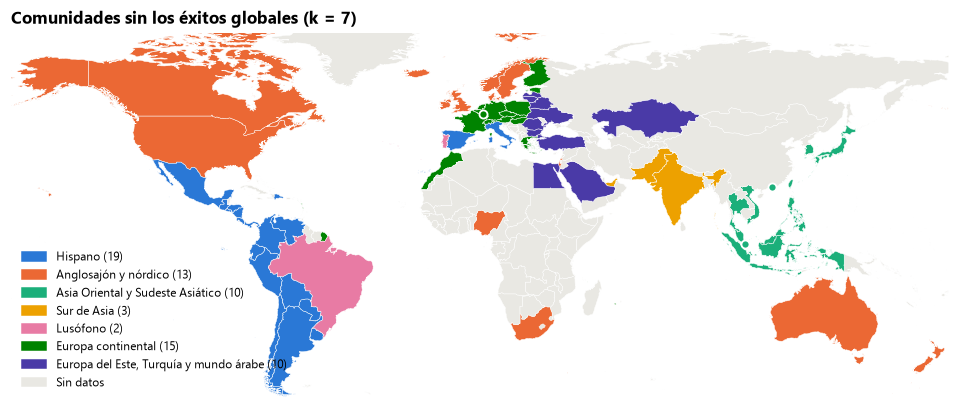

In [18]:
mapa(lab_local, nombres_local, f'Comunidades sin los éxitos globales (k = {k_local})', 'fig08_mapa_sin_globales')

**E3 — Red con pesos vs red sin pesos.** Se mantienen exactamente las mismas aristas (cada país sigue conectado con sus 12
más parecidos), pero todas valen 1: $a_{ij} = 1$ si hay arista y $0$ si no. Así se mide cuánto importa la **intensidad**
de cada conexión frente a solo saber quién está conectado con quién.

In [19]:
A_bin = (A > 0).astype(float)
lam_bin = np.linalg.eigvalsh(laplacianos(A_bin)[2])
gaps_bin = np.diff(lam_bin)
ranking_bin = [int(k) for k in np.argsort(gaps_bin[1:10])[::-1] + 2]
print('λ_1..λ_6 con pesos:', lam[:6].round(4))
print('λ_1..λ_6 sin pesos:', lam_bin[:6].round(4), f'| mayores saltos tras k = {ranking_bin[:2]}')

ANCLAS_BIN = [('MX', 'Hispano'), ('DE', 'Europa continental'), ('US', 'Anglosajón y otros'), ('JP', 'Asia y Medio Oriente')]
lab2_bin = clustering_espectral(A_bin, K_MACRO)
lab4_bin, nombres4_bin = ordenar_y_nombrar(clustering_espectral(A_bin, K_FINAL), ANCLAS_BIN)
from sklearn.metrics import adjusted_rand_score
filas_e3 = []
for nombre_red, l2, l4 in [('con pesos (base)', lab2, lab4), ('sin pesos', lab2_bin, lab4_bin)]:
    ev = evaluar(l4)          # modularidad medida siempre sobre la red con pesos, para comparar
    filas_e3.append({'red': nombre_red, 'λ₂': (lam if l4 is lab4 else lam_bin)[1],
                     'ARI con la base (k = 2)': adjusted_rand_score(lab2, l2), 'ARI con la base (k = 4)': adjusted_rand_score(lab4, l4),
                     'AMI continente': ev['AMI continente'], 'AMI idioma': ev['AMI idioma'], 'AMI clima': ev['AMI clima'],
                     'modularidad': ev['modularidad'], 'tamaños (k = 4)': ev['tamaños']})
e3 = pd.DataFrame(filas_e3).set_index('red')
e3.to_csv(RES / 'exp3_pesos.csv', encoding='utf-8-sig')
display(e3.round(4))
tabla_comunidades(lab4_bin, nombres4_bin)

λ_1..λ_6 con pesos: [0.000e+00 3.000e-04 3.133e-01 3.839e-01 6.606e-01 7.053e-01]
λ_1..λ_6 sin pesos: [0.     0.004  0.3365 0.6426 0.6985 0.788 ] | mayores saltos tras k = [2, 3]


,λ₂,ARI con la base (k = 2),ARI con la base (k = 4),AMI continente,AMI idioma,AMI clima,modularidad,tamaños (k = 4)
red,,,,,,,,
con pesos (base),0.0003,1.0,1.0000,0.5138,0.3134,0.1893,0.4854,18 / 33 / 19 / 2
sin pesos,0.0040,1.0,0.5547,0.5030,0.3559,0.1498,0.4362,18 / 25 / 15 / 14


,comunidad,tamaño,países
0,Hispano,18,"Argentina, Bolivia, Chile, Colombia, Costa Rica, Ecuador, El Salvador, España, Guatemala, Honduras, México, Nicaragu..."
1,Europa continental,25,"Alemania, Austria, Brasil, Bulgaria, Bélgica, Chequia, Eslovaquia, Estonia, Finlandia, Francia, Grecia, Hungría, Ind..."
2,Anglosajón y otros,15,"Australia, Canadá, Dinamarca, Egipto, Estados Unidos, Filipinas, Indonesia, Irlanda, Islandia, Israel, Nigeria, Nuev..."
3,Asia y Medio Oriente,14,"Arabia Saudita, Bielorrusia, Corea del Sur, Emiratos Árabes, Hong Kong, Japón, Kazajistán, Malasia, Marruecos, Pakis..."


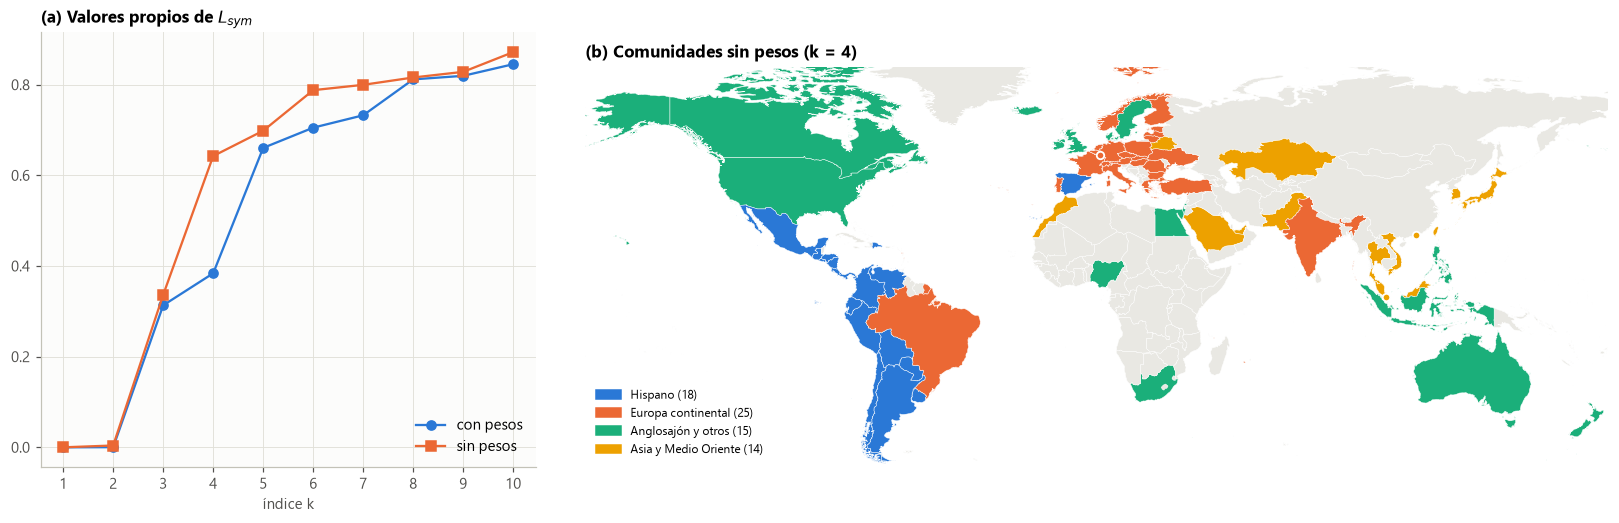

In [20]:
fig = plt.figure(figsize=(15, 5.2))
ax1 = fig.add_axes([0.04, 0.12, 0.3, 0.76])
ax1.plot(range(1, 11), lam[:10], marker='o', ms=6, lw=1.5, color=PALETA[0], label='con pesos')
ax1.plot(range(1, 11), lam_bin[:10], marker='s', ms=6, lw=1.5, color=PALETA[1], label='sin pesos')
ax1.set_xticks(range(1, 11))
ax1.set_xlabel('índice k')
ax1.set_title(r'(a) Valores propios de $L_{sym}$', fontsize=11)
ax1.legend(loc='lower right')
ax2 = fig.add_axes([0.37, 0.02, 0.62, 0.9])
colores_bin = {paises[i]: PALETA[lab4_bin[i]] for i in range(n)}
for feat in MUNDO['features']:
    iso = feat['properties'].get('ISO_A2_EH')
    if iso == 'AQ':
        continue
    geom = feat['geometry']
    for pol in (geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]):
        ax2.add_patch(PoligonoMpl(np.array(pol[0]), closed=True, facecolor=colores_bin.get(iso, SIN_DATO), edgecolor='white', linewidth=0.3))
for iso, (lo, la) in PEQUENOS.items():
    ax2.scatter(lo, la, s=24, color=colores_bin[iso], edgecolor='white', linewidth=1.2, zorder=3)
ax2.set_xlim(-170, 180)
ax2.set_ylim(-57, 80)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(f'(b) Comunidades sin pesos (k = {K_FINAL})', fontsize=11)
ax2.legend(handles=[Patch(color=PALETA[c], label=f'{nombres4_bin[c]} ({(lab4_bin == c).sum()})') for c in np.unique(lab4_bin)],
           loc='lower left', fontsize=8)
guardar(fig, 'fig09_sin_pesos')
plt.show()

**Interpretación.** Con $k=2$ la partición es idéntica: el bloque hispano no depende de los pesos. Sin pesos, $\lambda_2$ sube de
0,0003 a 0,004, porque la arista débil Japón–Perú pasa a valer lo mismo que cualquier otra. Con $k=4$ la partición cambia bastante
(ARI = 0,55): el mundo anglosajón se separa de Europa continental y desaparece el grupo India–Pakistán (India queda con Europa
continental, lo que no tiene sentido musical). Además, el *eigengap* ya no apoya $k=4$, y la modularidad baja de 0,49 a 0,44.
Conclusión: los pesos importan para la estructura fina, porque evitan que conexiones débiles cuenten igual que las fuertes.

## 9. Chile y países puente

**Índice de frontera:** fracción del peso de las aristas de un país que va hacia otras comunidades, $f_i = \sum_{j \notin C(i)} a_{ij} / d_i$.

In [21]:
frontera = pd.DataFrame({'nombre': meta['nombre'], 'comunidad': [nombres4[c] for c in lab4],
                         'índice de frontera': [A[i, lab4 != lab4[i]].sum() / d[i] for i in range(n)]}, index=paises)
display(frontera.sort_values('índice de frontera', ascending=False).head(6).round(3))

cl = pd.Series(S[idx['CL']], index=paises).drop('CL').nlargest(5)
print('Índice de frontera de Chile:', round(frontera.loc['CL', 'índice de frontera'], 3))
pd.DataFrame({'país': [META[c][0] for c in cl.index], 'similitud con Chile': cl.values.round(3)}, index=range(1, 6))

,nombre,comunidad,índice de frontera
RO,Rumania,"Asia, Medio Oriente y Europa del Este",0.661
BG,Bulgaria,"Asia, Medio Oriente y Europa del Este",0.658
UA,Ucrania,"Asia, Medio Oriente y Europa del Este",0.606
AE,Emiratos Árabes,"Asia, Medio Oriente y Europa del Este",0.602
EG,Egipto,"Asia, Medio Oriente y Europa del Este",0.554
PH,Filipinas,"Asia, Medio Oriente y Europa del Este",0.549


Índice de frontera de Chile: 0.0


,país,similitud con Chile
1,Perú,0.574
2,Bolivia,0.534
3,Paraguay,0.529
4,Ecuador,0.513
5,Venezuela,0.502


In [22]:
asignaciones = meta[['nombre', 'continente', 'idioma', 'clima']].copy()
asignaciones[f'comunidad k={K_MACRO}'] = [nombres2[c] for c in lab2]
asignaciones[f'comunidad k={K_FINAL}'] = [nombres4[c] for c in lab4]
asignaciones[f'sin éxitos globales (k={k_local})'] = [nombres_local[c] for c in lab_local]
asignaciones['índice de frontera'] = frontera['índice de frontera'].round(3)
asignaciones.to_csv(RES / 'comunidades_por_pais.csv', encoding='utf-8-sig')
evaluacion.to_csv(RES / 'evaluacion.csv', encoding='utf-8-sig')
e1.to_csv(RES / 'exp1_laplaciano.csv', encoding='utf-8-sig', index=False)
e2.to_csv(RES / 'exp2_exitos_globales.csv', encoding='utf-8-sig')
print('Resultados guardados en', RES)

Resultados guardados en resultados
